In [1]:

# GPR model training with hyperparameter tuning using grid search and validation using nested LOOCV

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor

from sklearn.gaussian_process.kernels import (
    RBF,
    Matern,
    RationalQuadratic,
    ConstantKernel
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, GridSearchCV

from sklearn.metrics import (
    r2_score,
    mean_squared_error
)


# Load data file

data  = "define the datafile path"
df = pd.read_csv(data)


# Input feature space
X_real = np.column_stack((
    df.TEMP,
    df.SPEED,
    df.INNOCULUM
   
))

#Target varible
y = df["SURFACTIN"].values

X = np.asarray(X_real)
y = np.asarray(y).ravel()

print("Number of observations:", X.shape[0])
print("Number of predictors:", X.shape[1])



# 2. Outer LOOCV

outer_loo = LeaveOneOut()

# Store prediction for every outer left-out observation
y_pred_LOOCV = np.zeros(len(y))

# Store best parameters from every outer fold
best_params = []



# 3. GPR pipeline

gpr_pipeline = Pipeline([
    
    ("scaler", StandardScaler()),

    ("gpr", GaussianProcessRegressor(
        normalize_y=True,
        random_state=42
    ))
])


# 4. Define hyperparameter grid

param_grid = [


    # RBF kernel
    {
        "gpr__kernel": [

            ConstantKernel(1.0) *
            RBF(length_scale=1.0)
        ],

        "gpr__alpha": [
            1e-6,
            1e-4,
            1e-3,
            1e-2,
            1e-1
        ]
    },


    # Rational Quadratic kernel


    {
        "gpr__kernel": [

            ConstantKernel(1.0) *
            RationalQuadratic(
                length_scale=1.0,
                alpha=1.0
            )
        ],

        "gpr__alpha": [
            1e-6,
            1e-4,
            1e-3,
            1e-2,
            1e-1
        ]
    }
]



# 5. Nested LOOCV

for fold, (train_idx, test_idx) in enumerate(
        outer_loo.split(X),
        start=1):

    print("\n" + "=" * 60)

    print(
        f"Outer LOOCV fold {fold}/{len(y)}"
    )

    print("=" * 60)



    # Outer training data
 

    X_train = X[train_idx]
    y_train = y[train_idx]


   
    # Outer test data
  

    X_test = X[test_idx]
    y_test = y[test_idx]


    print(
        f"Training observations = {len(train_idx)}"
    )

    print(
        f"Test observation       = {len(test_idx)}"
    )


    
    # Inner LOOCV

    inner_loo = LeaveOneOut()


    
    # Grid Search

    grid_search = GridSearchCV(

        estimator=gpr_pipeline,

        param_grid=param_grid,

        scoring="neg_mean_squared_error",

        cv=inner_loo,

        n_jobs=-1,

        refit=True
    )


    
    # Hyperparameter tuning

    grid_search.fit(

        X_train,

        y_train
    )


    
    # Best GPR model from inner LOOCV

    best_model = grid_search.best_estimator_


    
    # Store best parameters


    fold_params = grid_search.best_params_

    best_params.append(
        fold_params
    )



    # Predict outer held-out test observation
    

    prediction = best_model.predict(
        X_test
    )[0]


    y_pred_LOOCV[test_idx[0]] = prediction



    # Display results

    print(
        f"Observed  = {y_test[0]:.6f}"
    )

    print(
        f"Predicted = {prediction:.6f}"
    )

    print(
        "Best parameters:"
    )

    print(
        fold_params
    )



# 6. Nested LOOCV performance metrics


R2_LOOCV = r2_score(

    y,

    y_pred_LOOCV
)


RMSE_LOOCV = np.sqrt(

    
    mean_squared_error(

        y,

        y_pred_LOOCV
    )
)


print("\n")
print("=" * 60)

print(
    "GPR – Nested LOOCV performance metrics"
)

print("=" * 60)


print(
    f"LOOCV R²   = {R2_LOOCV:.4f}"
)

print(
    f"LOOCV RMSE = {RMSE_LOOCV:.4f}"
)



# 7. Final GPR hyperparameter optimization


print("\n")
print("=" * 60)

print(
    "Final GPR hyperparameter optimization"
)

print("=" * 60)


final_inner_loo = LeaveOneOut()


final_grid = GridSearchCV(

    estimator=gpr_pipeline,

    param_grid=param_grid,

    scoring="neg_mean_squared_error",

    cv=final_inner_loo,

    n_jobs=-1,

    refit=True
)



# Retrain using all 25 observations


final_grid.fit(

    X,

    y
)



# Final optimized GPR model


final_model = final_grid.best_estimator_


print(
    "Final optimal parameters:"
)

print(
    final_grid.best_params_
)



# 8. Final training predictions


y_train_pred = final_model.predict(
    X
)



# 9. Training performance metrics

R2_train = r2_score(

    y,

    y_train_pred
)


RMSE_train = np.sqrt(

    mean_squared_error(

        y,

        y_train_pred
    )
)


print("\n")
print("=" * 60)

print(
    "Training performance metrics"
)

print("=" * 60)


print(
    f"Train R²   = {R2_train:.4f}"
)

print(
    f"Train RMSE = {RMSE_train:.4f}"
)



# 10. Train vs nested LOOCV

print("\n")
print("=" * 60)

print(
    "Train vs nested LOOCV"
)

print("=" * 60)


print(
    f"Train R²   = {R2_train:.4f} | "
    f"LOOCV R²   = {R2_LOOCV:.4f}"
)

print(
    f"Train RMSE = {RMSE_train:.4f} | "
    f"LOOCV RMSE = {RMSE_LOOCV:.4f}"
)



# 11. Observed vs predicted

results = pd.DataFrame({

    "Observation":
        np.arange(
            1,
            len(y) + 1
        ),

    "Observed":
        y,

    "Train_Predicted":
        y_train_pred,

    "LOOCV_Predicted":
        y_pred_LOOCV
})


print("\n")

print(
    "Observed vs predicted:"
)

print(results)



# 12. Generating bootstrap samples


n_bootstrap = 10000

rng = np.random.default_rng(
    42
)


bootstrap_r2 = np.zeros(
    n_bootstrap
)


bootstrap_rmse = np.zeros(
    n_bootstrap
)


n = len(y)



# 13. Bootstrap resampling


for b in range(
        n_bootstrap):



    # Sample 25 observations with replacement
    

    indices = rng.integers(

        low=0,

        high=n,

        size=n
    )


    
    # Preserve observed-predicted pairs
    

    y_boot = y[
        indices
    ]

    y_pred_boot = y_pred_LOOCV[
        indices
    ]


    
    # Bootstrap R²

    bootstrap_r2[b] = r2_score(

        y_boot,

        y_pred_boot
    )


    
    # Bootstrap RMSE


    bootstrap_rmse[b] = np.sqrt(

        mean_squared_error(

            y_boot,

            y_pred_boot
        )
    )



# 14. 95% percentile CI


R2_CI_L = np.percentile(

    bootstrap_r2,

    2.5
)

R2_CI_U = np.percentile(

    bootstrap_r2,

    97.5
)


RMSE_CI_L = np.percentile(

    bootstrap_rmse,

    2.5
)

RMSE_CI_U = np.percentile(

    bootstrap_rmse,

    97.5
)



# 15. Final results


print("\n")
print("=" * 60)

print(
    "GPR + nested LOOCV+ Bootstrap results"
)

print("=" * 60)


print(
    f"Train R²   = {R2_train:.4f}"
)

print(
    f"Train RMSE = {RMSE_train:.4f}"
)

print()


print(
    f"LOOCV R²   = {R2_LOOCV:.4f}"
)

print(
    f"95% CI     = "
    f"[{R2_CI_L:.4f}, "
    f"{R2_CI_U:.4f}]"
)

print()


print(
    f"LOOCV RMSE = {RMSE_LOOCV:.4f}"
)

print(
    f"95% CI     = "
    f"[{RMSE_CI_L:.4f}, "
    f"{RMSE_CI_U:.4f}]"
)



# 16. Best hyperparameters from outer LOOCV folds


print("\n")
print("=" * 60)

print(
    "Best hyperparameters from outer LOOCV folds"
)

print("=" * 60)


for i, params in enumerate(

        best_params,

        start=1):

    print(

        f"Fold {i:02d}: "
        f"{params}"
    )


Number of observations: 25
Number of predictors: 3

Outer LOOCV fold 1/25
Training observations = 24
Test observation       = 1
Observed  = 3.510000
Predicted = 2.318644
Best parameters:
{'gpr__alpha': 0.0001, 'gpr__kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=1)}

Outer LOOCV fold 2/25
Training observations = 24
Test observation       = 1
Observed  = 1.600000
Predicted = 1.867036
Best parameters:
{'gpr__alpha': 1e-06, 'gpr__kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=1)}

Outer LOOCV fold 3/25
Training observations = 24
Test observation       = 1
Observed  = 5.910000
Predicted = 5.679824
Best parameters:
{'gpr__alpha': 0.0001, 'gpr__kernel': 1**2 * RBF(length_scale=1)}

Outer LOOCV fold 4/25
Training observations = 24
Test observation       = 1
Observed  = 2.010000
Predicted = 1.514617
Best parameters:
{'gpr__alpha': 1e-06, 'gpr__kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=1)}

Outer LOOCV fold 5/25
Training observations = 24
Test observation       =

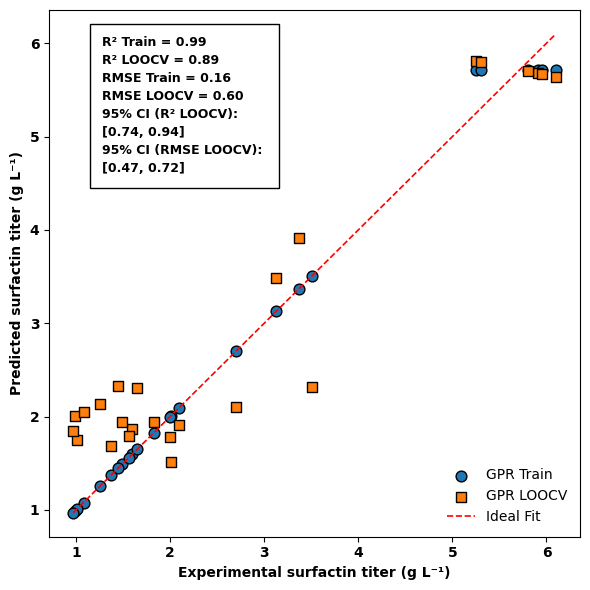

In [21]:
# Parity plots

plt.figure(figsize=(6,6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Train parity plot
plt.scatter(y, y_train_pred,
            color='#1f77b4', edgecolor='black',
            linewidth=1.0, marker='o', s=60,
            label='GPR Train')



# LOOCV parity plot
plt.scatter(y, y_pred_LOOCV,
            color='#ff7f0e', edgecolor='black',
            linewidth=1.0, marker='s', s=60,
            label='GPR LOOCV')



# range of y train data
min_val_train = min(
    y.min(),
    y_train_pred.min()
)

max_val_train = max(
    y.max(),
    y_train_pred.max()
)

# range of predicted y data
min_val_loo = min(
    y.min(),
    y_pred_LOOCV.min()
)

max_val_loo = max(
    y.max(),
    y_pred_LOOCV.max()
)


# 45 degree line
plt.plot([min_val_train, max_val_train], [min_val_loo, max_val_loo],
         color='red', linestyle='--', linewidth=1.2,
         label='Ideal Fit')


textstr = (
    f"R² Train = {R2_train:.2f}\n"
    f"R² LOOCV = {R2_LOOCV:.2f}\n"
    f"RMSE Train = {RMSE_train:.2f}\n"
    f"RMSE LOOCV = {RMSE_LOOCV:.2f} \n"
    f"95% CI (R² LOOCV): \n"
    f"[{R2_CI_L:.2f}, {R2_CI_U:.2f}]\n"
    f"95% CI (RMSE LOOCV): \n"
    f"[{RMSE_CI_L:.2f}, {RMSE_CI_U:.2f}]"
)


plt.text(0.1, 0.95, textstr,
         transform=ax.transAxes,
         fontsize=9,
         fontweight='bold',
         verticalalignment='top',
         linespacing=1.5,
         bbox=dict(boxstyle='square,pad=1',
                   facecolor='white',
                   edgecolor='black',
                   linewidth=1.0))   # bold border

leg = plt.legend(
    frameon=False,
    # prop={'size':10, 'weight': 'bold'}
    prop={'weight': 'bold', 'size': 10}
)

for text in leg.get_texts():
    text.set_fontweight('normal')

# LABELS
plt.xlabel("Experimental surfactin titer (g L⁻¹)", fontweight='bold')
plt.ylabel("Predicted surfactin titer (g L⁻¹)", fontweight='bold')
# plt.title("Model Comparison", fontweight='bold')


# Make axis appear bold

ax.tick_params(axis='both', labelsize=10)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')


plt.savefig("SVR_Performance_Final.png", dpi=1000, bbox_inches='tight')

plt.tight_layout()
plt.show()



In [3]:

# Display optimized GPR hyperparameters

# Grid-search selected parameters
print("\nGrid-search selected parameters:")
print(f"alpha (noise) = {grid_search.best_params_['gpr__alpha']}")
print(f"kernel        = {grid_search.best_params_['gpr__kernel']}")


# Extract the fitted GPR
gpr_fold = best_model.named_steps["gpr"]


# Optimized kernel after maximizing log marginal likelihood
print("\nOptimized kernel:")
print(gpr_fold.kernel_)


# Log marginal likelihood of optimized kernel
print(
    f"Log marginal likelihood = "
    f"{gpr_fold.log_marginal_likelihood_value_:.6f}"
)


Grid-search selected parameters:
alpha (noise) = 1e-06
kernel        = 1**2 * RationalQuadratic(alpha=1, length_scale=1)

Optimized kernel:
0.866**2 * RationalQuadratic(alpha=0.379, length_scale=0.847)
Log marginal likelihood = -99241.525208


In [27]:
# Prediction + future observation uncertainty


X_new = np.array([
    [33.5, 175.6, 7.53],
    [35, 170, 5],
    [36, 160, 6],
    [32, 173, 7],
    [33, 172, 8],
    [33.8, 142,6.3]
])


# Extract fitted GPR
gpr = final_model.named_steps["gpr"]


# Predict GP mean and latent-function standard deviation
y_mean, y_std = final_model.predict(
    X_new,
    return_std=True
)


# Observation-noise variance on actual surfactin (y) scale

noise_variance = (
    gpr.alpha *
    gpr._y_train_std**2
)


noise_std = np.sqrt(
    noise_variance
)


# Future noisy observation uncertainty

future_std = np.sqrt(
    y_std**2 +
    noise_variance
)



# 95% prediction interval

lower_95 = (
    y_mean -
    1.96 * future_std
)

upper_95 = (
    y_mean +
    1.96 * future_std
)



# Display results

print("\n")
print("=" * 70)
print("GPR future observation predictions")
print("=" * 70)

print(
    f"Selected alpha = {gpr.alpha:.6g}"
)

print(
    f"Estimated noise SD = {noise_std:.6f}"
)

for i in range(len(X_new)):

    print(
        f"\nSample {i+1}"
    )

    print(
        f"Predicted y = {y_mean[i]:.6f}"
    )

    print(
        f"Future observation SD = "
        f"{future_std[i]:.6f}"
    )

    print(
        f"95% Prediction Interval = "
        f"[{lower_95[i]:.6f}, "
        f"{upper_95[i]:.6f}]"
    )



GPR future observation predictions
Selected alpha = 1e-06
Estimated noise SD = 0.001794

Sample 1
Predicted y = 5.720149
Future observation SD = 0.028100
95% Prediction Interval = [5.665074, 5.775225]

Sample 2
Predicted y = 2.891326
Future observation SD = 0.898691
95% Prediction Interval = [1.129892, 4.652760]

Sample 3
Predicted y = 2.187880
Future observation SD = 0.837283
95% Prediction Interval = [0.546806, 3.828954]

Sample 4
Predicted y = 3.665472
Future observation SD = 0.833091
95% Prediction Interval = [2.032613, 5.298330]

Sample 5
Predicted y = 5.200752
Future observation SD = 0.485744
95% Prediction Interval = [4.248695, 6.152810]

Sample 6
Predicted y = 3.130000
Future observation SD = 0.002536
95% Prediction Interval = [3.125029, 3.134972]


In [5]:
from scipy.optimize import differential_evolution


# OPTIMIZATION OF PROCESS VARIABLES                                              (OPTIMAL PARAMETERS AND YIELD)
bounds = [
    (30, 37),      # Temperature
    (100, 250),    # Speed
    (2.5, 12.5)      # Inoculum
]

def objective_function(x):

    temp, speed, inoc = x

    X_input = np.array([[
        temp,
        speed,
        inoc      
    ]])

    y_pred = final_model.predict(X_input)[0]

    return -y_pred

result = differential_evolution(
    objective_function,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=15,
    tol=1e-6,
    polish=True,
    seed=42
)

optimal_temp, optimal_speed, optimal_inoc = result.x

X_optimal = np.array([[
    optimal_temp,
    optimal_speed,
    optimal_inoc
   
]])

optimal_output = final_model.predict(X_optimal)[0]

print("\n===== OPTIMAL PROCESS CONDITIONS =====")

print(f"Temperature : {optimal_temp:.4f} °C")
print(f"Speed       : {optimal_speed:.4f} rpm")
print(f"Inoculum    : {optimal_inoc:.4f} %")

print(f"\n Predicted Maximum Surfactin : {optimal_output:.4f}")


===== OPTIMAL PROCESS CONDITIONS =====
Temperature : 33.5294 °C
Speed       : 175.5931 rpm
Inoculum    : 7.5342 %

 Predicted Maximum Surfactin : 5.7213


Number of observations on T-S surface: 10
Number of observations on T-I surface: 10
Number of observations on S-I surface: 10


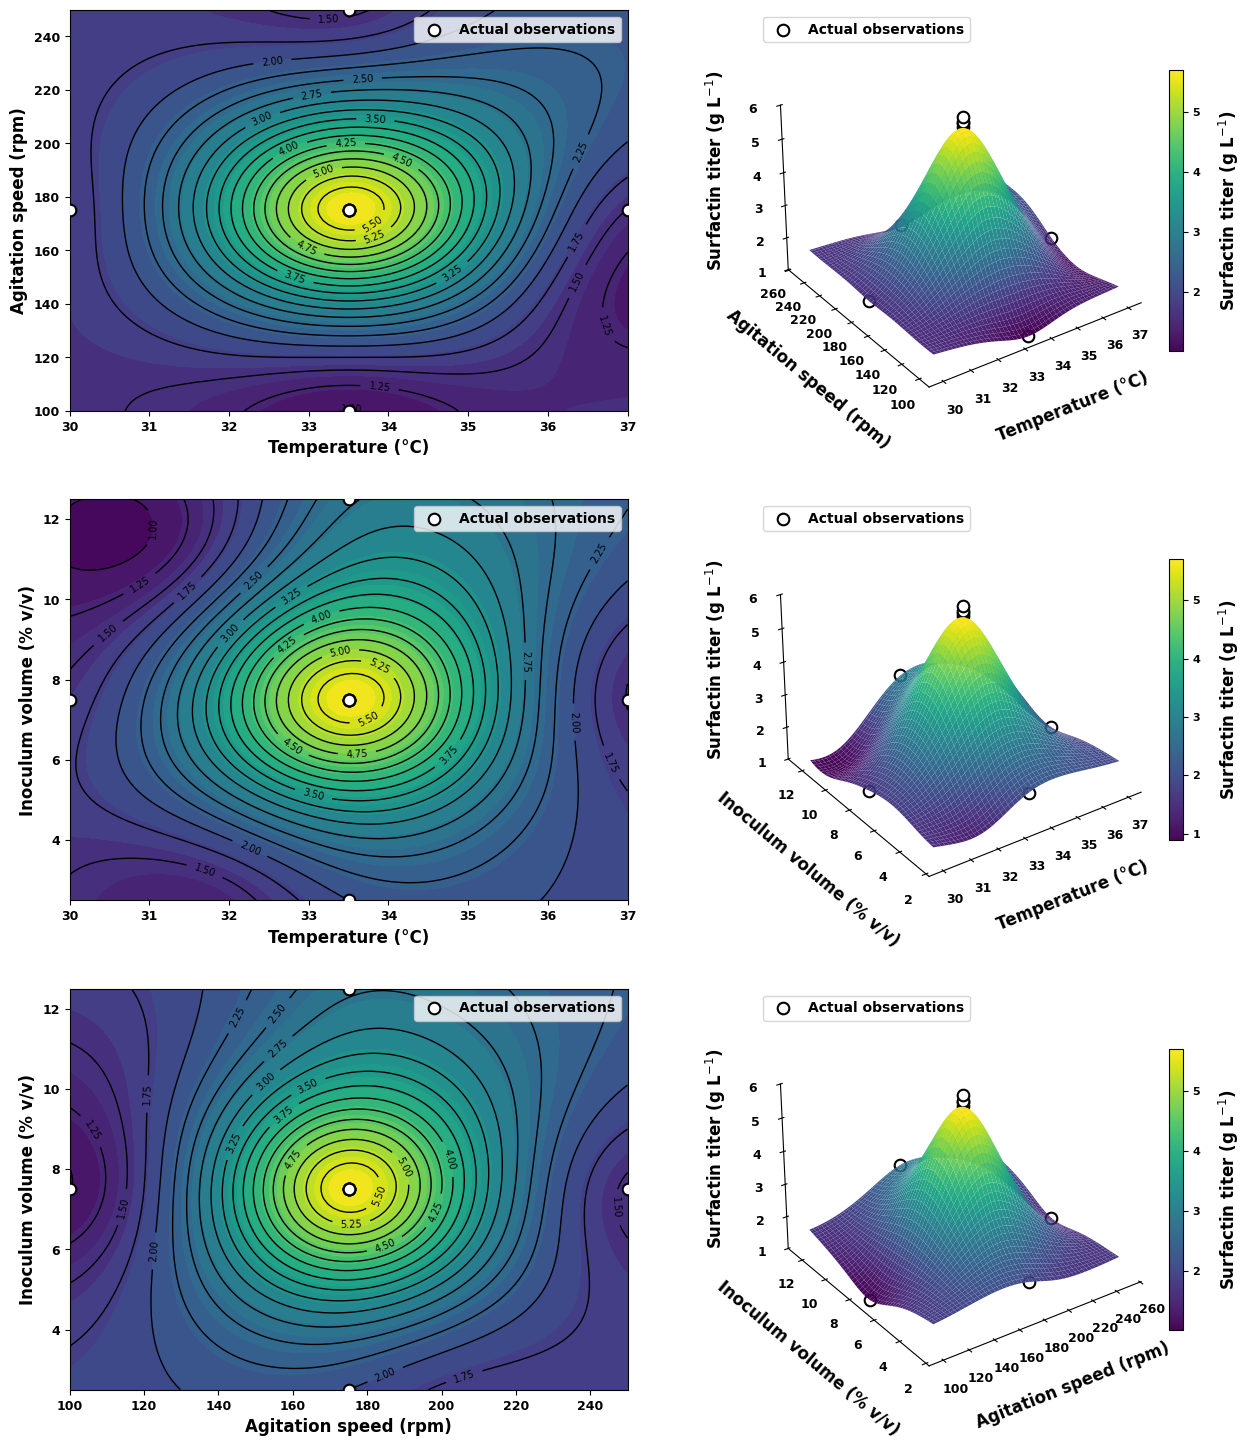

In [28]:

T = df["TEMP"].values
S = df["SPEED"].values
I = df["INNOCULUM"].values
y = df["SURFACTIN"].values



# Prediction function given by the GPR model ( posterior mean and covariance)

def predict_surface(T, S, I):

    X_input = np.column_stack([
        T,
        S,
        I
    ])

    y_mean, y_std = final_model.predict(
        X_input,
        return_std=True
    )

    return y_mean, y_std



# Constant values of the input features (centre values of the CCD)
T_const = 33.5
S_const = 175
I_const = 7.5




# Actual observation masks

# Temp-Speed surface: Inoculum fixed at 7.5 
mask_TS = np.isclose(
    I,
    I_const
)

# Temp-Inoculum surface: Speed fixed at 175
mask_TI = np.isclose(
    S,
    S_const
)

# Speed-Inoculum surface: Temp fixed at 33.5
mask_SI = np.isclose(
    T,
    T_const
)



# Print number of actual obbservations on the 2D surfaces

print(
    "Number of observations on T-S surface:",
    np.sum(mask_TS)
)

print(
    "Number of observations on T-I surface:",
    np.sum(mask_TI)
)

print(
    "Number of observations on S-I surface:",
    np.sum(mask_SI)
)



# Plots

fig = plt.figure(
    figsize=(13, 15)
)



# 3D Figures


def style_3d(ax):

    ax.grid(False)

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.xaxis.pane.set_edgecolor('white')
    ax.yaxis.pane.set_edgecolor('white')
    ax.zaxis.pane.set_edgecolor('white')

    ax.tick_params(
        axis='both',
        labelsize=9
    )

    for tick in (
        ax.get_xticklabels()
        + ax.get_yticklabels()
        + ax.get_zticklabels()
    ):
        tick.set_fontweight('bold')

    ax.view_init(
        elev=30,
        azim=-125
    )

    ax.set_box_aspect(
        (1.15, 1.15, 0.85)
    )



# 2D Figures


def style_2d(ax):

    ax.tick_params(
        axis='both',
        labelsize=9
    )

    for tick in (
        ax.get_xticklabels()
        + ax.get_yticklabels()
    ):
        tick.set_fontweight('bold')



# Create 2D contours

def create_contour(
        ax,
        X,
        Y,
        Z,
        xlabel,
        ylabel):

    contour = ax.contourf(
        X,
        Y,
        Z,
        levels=25,
        cmap='viridis'
    )

    lines = ax.contour(
        X,
        Y,
        Z,
        levels=20,
        colors='black',
        linewidths=1.0
    )

    ax.clabel(
        lines,
        inline=True,
        fontsize=7,
        fmt="%.2f"
    )

    ax.set_xlabel(
        xlabel,
        fontsize=12,
        fontweight='bold'
    )

    ax.set_ylabel(
        ylabel,
        fontsize=12,
        fontweight='bold'
    )

    style_2d(ax)

    return contour



# Create 3D surface


def create_surface(
        ax,
        X,
        Y,
        Z,
        xlabel,
        ylabel):

    surf = ax.plot_surface(
        X,
        Y,
        Z,
        cmap='viridis',
        edgecolor='none',
        alpha=0.98,
        antialiased=True
    )

    ax.set_xlabel(
        xlabel,
        fontsize=12,
        fontweight='bold',
        labelpad=12
    )

    ax.set_ylabel(
        ylabel,
        fontsize=12,
        fontweight='bold',
        labelpad=12
    )

    # Create Z label
    

    ax.set_zlabel("")

    ax.text2D(
        -0.10,
        0.60,
        "Surfactin titer (g L$^{-1}$)",
        transform=ax.transAxes,
        rotation=90,
        fontsize=12,
        fontweight='bold',
        va='center',
        ha='center'
    )


    # Z-axis range

    ax.set_zlim(
        1,
        6
    )

    ax.set_zticks(
        np.arange(1, 7, 1)
    )

    style_3d(ax)

    
    # Colorbar
    
    cbar = fig.colorbar(
        surf,
        ax=ax,
        shrink=0.70,
        pad=0.02
    )

    cbar.set_label(
        "Surfactin titer (g L$^{-1}$)",
        fontsize=12,
        fontweight='bold',
        rotation=90,
        labelpad=12
    )

    cbar.ax.tick_params(
        labelsize=8
    )

    for tick in cbar.ax.get_yticklabels():
        tick.set_fontweight('bold')

    return surf



# 2D and 3D subplots

ax1 = fig.add_subplot(
    3, 2, 1
)

ax2 = fig.add_subplot(
    3, 2, 2,
    projection='3d'
)

ax3 = fig.add_subplot(
    3, 2, 3
)

ax4 = fig.add_subplot(
    3, 2, 4,
    projection='3d'
)

ax5 = fig.add_subplot(
    3, 2, 5
)

ax6 = fig.add_subplot(
    3, 2, 6,
    projection='3d'
)




# Temp vs Speed
# Inoculum = 7.5 


T_range = np.linspace(
    30,
    37,
    100
)

S_range = np.linspace(
    100,
    250,
    100
)

X1, Y1 = np.meshgrid(
    T_range,
    S_range
)

T1 = X1.ravel()
S1 = Y1.ravel()

I1 = np.full_like(
    T1,
    I_const
)



# GPR predictions

Z1_mean, Z1_std = predict_surface(
    T1,
    S1,
    I1
)

Z1_mean = Z1_mean.reshape(
    X1.shape
)

Z1_std = Z1_std.reshape(
    X1.shape
)



# 2D Temp-Speed contour


create_contour(
    ax1,
    X1,
    Y1,
    Z1_mean,
    "Temperature (°C)",
    "Agitation speed (rpm)"
)



# Actual observations on 2D Temp-Speed

ax1.scatter(
    T[mask_TS],
    S[mask_TS],
    s=70,
    marker='o',
    facecolor='white',
    edgecolor='black',
    linewidth=1.5,
    label='Actual observations',
    zorder=10
)

ax1.legend(
    loc='best',
    fontsize=9,
    prop={'weight': 'bold'}
)



# 3D Temp-Speed surface


create_surface(
    ax2,
    X1,
    Y1,
    Z1_mean,
    "Temperature (°C)",
    "Agitation speed (rpm)"
)



# Actual observations on 3D Temp-Speed


ax2.scatter(
    T[mask_TS],
    S[mask_TS],
    y[mask_TS],
    s=70,
    marker='o',
    facecolor='white',
    edgecolor='black',
    linewidth=1.5,
    label='Actual observations',
    depthshade=False
)

ax2.legend(
    loc='upper left',
    fontsize=9,
    prop={'weight': 'bold'}
)



# Temp vs Inoculum
# Speed = 175


T_range = np.linspace(
    30,
    37,
    100
)

I_range = np.linspace(
    2.5,
    12.5,
    100
)

X2, Y2 = np.meshgrid(
    T_range,
    I_range
)

T2 = X2.ravel()
I2 = Y2.ravel()

S2 = np.full_like(
    T2,
    S_const
)



# GPR prediction

Z2_mean, Z2_std = predict_surface(
    T2,
    S2,
    I2
)

Z2_mean = Z2_mean.reshape(
    X2.shape
)

Z2_std = Z2_std.reshape(
    X2.shape
)



# 2D T-I CONTOUR

create_contour(
    ax3,
    X2,
    Y2,
    Z2_mean,
    "Temperature (°C)",
    "Inoculum volume (% v/v)"
)



# Actual observations on 2D T-I

ax3.scatter(
    T[mask_TI],
    I[mask_TI],
    s=70,
    marker='o',
    facecolor='white',
    edgecolor='black',
    linewidth=1.5,
    label='Actual observations',
    zorder=10
)

ax3.legend(
    loc='best',
    fontsize=9,
    prop={'weight': 'bold'}
)



# 3D T-I surface

create_surface(
    ax4,
    X2,
    Y2,
    Z2_mean,
    "Temperature (°C)",
    "Inoculum volume (% v/v)"
)



# Actual observations on 3D T-I


ax4.scatter(
    T[mask_TI],
    I[mask_TI],
    y[mask_TI],
    s=70,
    marker='o',
    facecolor='white',
    edgecolor='black',
    linewidth=1.5,
    label='Actual observations',
    depthshade=False
)

ax4.legend(
    loc='upper left',
    fontsize=9,
    prop={'weight': 'bold'}
)



# Speed vs Inoculum
# T = CONSTANT = 33.5


S_range = np.linspace(
    100,
    250,
    100
)

I_range = np.linspace(
    2.5,
    12.5,
    100
)

X3, Y3 = np.meshgrid(
    S_range,
    I_range
)

S3 = X3.ravel()
I3 = Y3.ravel()

T3 = np.full_like(
    S3,
    T_const
)



# GPR predictions

Z3_mean, Z3_std = predict_surface(
    T3,
    S3,
    I3
)

Z3_mean = Z3_mean.reshape(
    X3.shape
)

Z3_std = Z3_std.reshape(
    X3.shape
)



# 2D S-I contour


create_contour(
    ax5,
    X3,
    Y3,
    Z3_mean,
    "Agitation speed (rpm)",
    "Inoculum volume (% v/v)"
)



# Actual observations on 2D S-I


ax5.scatter(
    S[mask_SI],
    I[mask_SI],
    s=70,
    marker='o',
    facecolor='white',
    edgecolor='black',
    linewidth=1.5,
    label='Actual observations',
    zorder=10
)

ax5.legend(
    loc='best',
    fontsize=9,
    prop={'weight': 'bold'}
)


# 3D S-I SURFACE

create_surface(
    ax6,
    X3,
    Y3,
    Z3_mean,
    "Agitation speed (rpm)",
    "Inoculum volume (% v/v)"
)


# Actual observations on 3D S-I


ax6.scatter(
    S[mask_SI],
    I[mask_SI],
    y[mask_SI],
    s=70,
    marker='o',
    facecolor='white',
    edgecolor='black',
    linewidth=1.5,
    label='Actual observations',
    depthshade=False
)

ax6.legend(
    loc='upper left',
    fontsize=9,
    prop={'weight': 'bold'}
)


# Adjust spacing

plt.subplots_adjust(
    left=0.06,
    right=0.97,
    top=0.97,
    bottom=0.05,
    wspace=0.12,
    hspace=0.22
)



# Saving the 2D and 3D surface plots

plt.savefig(
    "Final Combined_2D_3D_Response_Surface.png",
    dpi=1200,
    bbox_inches='tight'
)

plt.show()
